# Model 6 — Ensemble (HW + SARIMA)

Gabungan Holt-Winters & SARIMA dengan bobot inverse-error.

Notebook ini **mandiri**: menjalankan seluruh tahapan dari *preprocessing* sampai *modeling* untuk satu pendekatan.

**Tahapan:**
1. Setup & import
2. Muat data mentah (`load_raw`)
3. Pembersihan (`clean`)
4. Pembentukan panel bulanan (`build_panel`) + EDA
5. Segmentasi obat (K-Means clustering)
6. Split temporal (anti-leakage)
7. Feature engineering & training model
8. Evaluasi (MAE/RMSE/MAPE/sMAPE/R²)
9. Simpan artefak
10. Contoh prediksi + rekomendasi restok

## 1. Setup & Import
Modul forecasting yang sudah ada **dipakai ulang** (tidak ditulis ulang).

In [1]:
import os, sys, json, time, warnings
warnings.filterwarnings('ignore')
# agar `import config` dst. dikenali saat notebook ada di subfolder
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import config as C
import data_processing as dp
import clustering as clu
import ml_features as F
from restock import hitung_restock
from pipeline_forecasting_obat import (
    temporal_split, evaluate, compute_ensemble_weights)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# folder artefak notebook (tidak menimpa models/ produksi)
NB_MODELS = C.BASE_DIR / 'models_nb'
NB_MODELS.mkdir(exist_ok=True)
print('Setup OK. Artefak ->', NB_MODELS)

Setup OK. Artefak -> D:\jurnal\DATA\New folder\restock_forecasting\models_nb


## 2. Muat Data Mentah
Sumber: `Rekap_2025_Gabungan_Terisi.xlsx` sheet *Rekap Kunjungan*. Kolom `JUMLAH` & `SISA_STOK` adalah agregat bulanan per obat (broadcast).

In [2]:
raw = dp.load_raw()
print('Baris mentah:', len(raw))
print('Kolom:', list(raw.columns))
raw.head()

Baris mentah: 20675
Kolom: ['Tanggal Masuk', 'Register', 'Kode Diagnosa', 'Diagnosa Primer', 'Resep Obat', 'JUMLAH', 'SISA_STOK', 'SATUAN']


,Tanggal Masuk,Register,Kode Diagnosa,Diagnosa Primer,Resep Obat,JUMLAH,SISA_STOK,SATUAN
0,2025-01-06,1665,J06.9,"Acute upper respiratory infection, unspecified",AMBROXOL SIRUP,NaN,NaN,NaN
1,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",ACETYLCYSTEIN KAP,471.0,3953.0,KAPSUL
2,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",BECEFORT TAB,380.0,925.0,TABLET
3,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB,1194.0,2644.0,TABLET
4,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",PAMOL TAB 500MG (PARACETAMOL TAB),NaN,NaN,NaN


## 3. Pembersihan (`clean`)
Parse tanggal, normalisasi nama obat (strip+upper), buang baris tak valid, dedup, tambah kolom periode bulanan.

In [3]:
df = dp.clean(raw)
print('Setelah clean:', len(df), 'baris |', df[C.P_OBAT].nunique(), 'obat unik')
df[[C.COL_DATE, C.P_OBAT, C.COL_QTY, C.COL_STOCK, C.P_PERIOD]].head()

Setelah clean: 20149 baris | 248 obat unik


,Tanggal Masuk,obat,JUMLAH,SISA_STOK,periode
0,2025-01-06,AMBROXOL SIRUP,NaN,NaN,2025-01
1,2025-01-06,ACETYLCYSTEIN KAP,471.0,3953.0,2025-01
2,2025-01-06,BECEFORT TAB,380.0,925.0,2025-01
3,2025-01-06,NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB,1194.0,2644.0,2025-01
4,2025-01-06,PAMOL TAB 500MG (PARACETAMOL TAB),NaN,NaN,2025-01


## 4. Panel Bulanan (`build_panel`) + EDA
`first()` non-null per (obat, bulan) **anti double-count**, reindex 12 bulan (Jan–Des 2025; Nov hilang → diisi interpolasi), isi celah.

Panel: 1572 baris = 131 obat x 12 bulan
Observasi asli: 805 (51.2%)


,periode,obat,demand,stok,satuan,is_observed
0,2025-01,ACETYLCYSTEIN KAP,471.0,3953.0,KAPSUL,True
1,2025-02,ACETYLCYSTEIN KAP,1368.0,2346.0,KAPSUL,True
2,2025-03,ACETYLCYSTEIN KAP,570.0,2634.0,KAPSUL,True
3,2025-04,ACETYLCYSTEIN KAP,396.0,2238.0,KAPSUL,True
4,2025-05,ACETYLCYSTEIN KAP,419.0,2319.0,KAPSUL,True


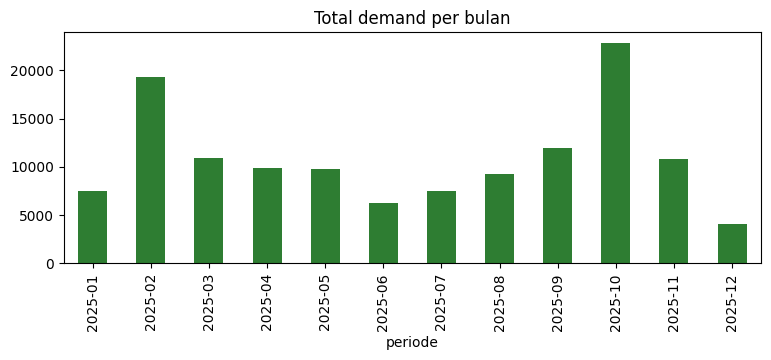

In [4]:
panel = dp.build_panel(df)
print('Panel:', len(panel), 'baris =', panel[C.P_OBAT].nunique(), 'obat x',
      panel[C.P_PERIOD].nunique(), 'bulan')
print('Observasi asli:', int(panel[C.P_IS_OBS].sum()),
      f"({100*panel[C.P_IS_OBS].mean():.1f}%)")
display(panel.head())
panel.groupby(C.P_PERIOD)[C.P_DEMAND].sum().plot(
    kind='bar', figsize=(9,3), title='Total demand per bulan', color='#2e7d32');

## 5. Segmentasi Obat (K-Means)
Fitur per obat: volume, cv (stabilitas), frekuensi, stok. K optimal via silhouette. Segmen dipakai sebagai konteks (dan fitur untuk model ML).

In [5]:
# [Perbaikan audit C-01] Cluster & scaler di-fit HANYA pada periode TRAIN
# (anti-leakage): bulan test (Nov/Des) tidak boleh ikut menentukan fitur 'cluster'.
_periods_all = sorted(panel[C.P_PERIOD].unique())
_train_p = _periods_all[:-C.TEST_MONTHS]
panel_cluster = panel[panel[C.P_PERIOD].isin(_train_p)].copy()
feat = clu.build_features(panel_cluster)
Xraw = clu.transform_features(feat)
scaler = StandardScaler(); X = scaler.fit_transform(Xraw)
best_k, scores = clu.choose_k(X)
km = KMeans(n_clusters=best_k, random_state=C.KMEANS_RANDOM_STATE, n_init=10)
feat['cluster'] = km.fit_predict(X)
labels, agg = clu.label_clusters(feat)
feat['segmen'] = feat['cluster'].map(labels)
cluster_map = {r[C.P_OBAT]: {'cluster': int(r['cluster']), 'label': r['segmen']}
               for _, r in feat.iterrows()}
print('K optimal =', best_k)
print(feat['segmen'].value_counts().to_string())

K optimal = 3
segmen
Slow-moving fluktuatif    58
Fast-moving stabil        44
Medium-moving stabil      29


## 6. Split Temporal (anti-leakage)
2 bulan terakhir = **test**, sisanya = **train**. Tidak ada bulan test bocor ke train.

In [6]:
train, test, train_periods, test_periods = temporal_split(panel)
print('Train:', train_periods)
print('Test :', test_periods)

Train: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10']
Test : ['2025-11', '2025-12']


## 7. Komponen Ensemble (Holt-Winters + SARIMA)
Ensemble menggabungkan HW & SARIMA. Bobot per obat = inverse |error| validasi internal (anti-leakage). Dua varian: **simple** (rata-rata) & **weighted**.

In [7]:
from forecaster import HoltWintersForecaster, SarimaForecaster, EnsembleForecaster
t0=time.time()
hw_eval = HoltWintersForecaster.fit(train)
sa_eval = SarimaForecaster.fit(train)
w_eval = compute_ensemble_weights(train, train_periods)
print(f'Fit komponen (train) {time.time()-t0:.1f}s')

D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit komponen (train) 72.3s


## 8. Evaluasi kedua varian

In [8]:
fc_simple = EnsembleForecaster(hw_eval, sa_eval, w_eval, 'simple')
fc_weighted = EnsembleForecaster(hw_eval, sa_eval, w_eval, 'weighted')
for nm, fcx in [('Ensemble (simple)', fc_simple), ('Ensemble (weighted)', fc_weighted)]:
    m = evaluate(fcx, test, test_periods, C.TEST_MONTHS, nm)
    print(nm, '->', {k: round(v,3) if isinstance(v,float) else v for k,v in m.items()})

Ensemble (simple)

 -> {'Model': 'Ensemble (simple)', 'MAE': 99.397, 'RMSE': 357.573, 'MAPE(%)': 180.656, 'sMAPE(%)': 138.084, 'R2': -2.571, 'n': 262}
Ensemble (weighted) -> {'Model': 'Ensemble (weighted)', 'MAE': 103.393, 'RMSE': 425.275, 'MAPE(%)': 185.249, 'sMAPE(%)': 123.353, 'R2': -4.051, 'n': 262}


## 🔧 Perbaikan Audit (diterapkan)
Menanggapi audit pipeline: **C-01** clustering di-fit *train-only* (sel segmentasi di atas), **W-06** baseline Naive sebagai pembanding, **W-02** metrik **Des-only** (holdout nyata; Nov = imputasi), **W-04** backtest *rolling-origin* (MAE mean ± std).

In [9]:
# Ensemble weighted dipakai sebagai model representatif (artefak produksi)
fc_eval = EnsembleForecaster(hw_eval, sa_eval, w_eval, 'weighted')
metrik = evaluate(fc_eval, test, test_periods, C.TEST_MONTHS, 'Ensemble (weighted)')

# ===== PERBAIKAN AUDIT (diterapkan) =====
import matplotlib.pyplot as plt
from forecaster import NaiveForecaster
dec = test_periods[-1]                      # '2025-12' = holdout NYATA (Nov = imputasi)
test_dec = test[test[C.P_PERIOD] == dec]

m_naive = evaluate(NaiveForecaster.fit(train), test, test_periods, C.TEST_MONTHS, 'Naive (baseline)')
print('[W-06] Baseline Naive :', {k: round(v,3) if isinstance(v,float) else v for k,v in m_naive.items()})
print('       Model kalahkan baseline (MAE lebih kecil)?', metrik['MAE'] < m_naive['MAE'])

m_dec = evaluate(fc_eval, test_dec, [dec], C.TEST_MONTHS, 'Des-only (NYATA)')
print('[W-02] Metrik Des-only:', {k: round(v,3) if isinstance(v,float) else v for k,v in m_dec.items()})

# [W-04] Backtest rolling-origin (expanding window) -> MAE mean +/- std (lebih robust dari 1 split)
def _bt_fit(trp):
    _tp = sorted(trp[C.P_PERIOD].unique())
    _hw = HoltWintersForecaster.fit(trp)
    _sa = SarimaForecaster.fit(trp)
    _w = compute_ensemble_weights(trp, _tp)
    return EnsembleForecaster(_hw, _sa, _w, 'weighted')
_allp = sorted(panel[C.P_PERIOD].unique())
_cutoffs = ['2025-06','2025-07','2025-08','2025-09']   # target Jul..Okt (semua observasi NYATA)
_bt = []
for _co in _cutoffs:
    _nxt = _allp[_allp.index(_co)+1]
    _fc = _bt_fit(panel[panel[C.P_PERIOD] <= _co])
    _act = panel[panel[C.P_PERIOD]==_nxt].set_index(C.P_OBAT)[C.P_DEMAND]
    _e = [abs(_fc.predict(o,1)['prediksi'][0]-float(_act.loc[o])) for o in _fc.history if o in _act.index]
    _bt.append(float(np.mean(_e)))
print('[W-04] Backtest MAE per origin (target Jul..Okt):', [round(x,2) for x in _bt])
print(f'       Backtest MAE = {np.mean(_bt):.2f} +/- {np.std(_bt):.2f}')


[W-06] Baseline Naive : {'Model': 'Naive (baseline)', 'MAE': 120.065, 'RMSE': 410.945, 'MAPE(%)': 171.93, 'sMAPE(%)': 105.612, 'R2': -3.717, 'n': 262}
       Model kalahkan baseline (MAE lebih kecil)? True
[W-02] Metrik Des-only: {'Model': 'Des-only (NYATA)', 'MAE': 134.555, 'RMSE': 499.642, 'MAPE(%)': 325.337, 'sMAPE(%)': 138.01, 'R2': -32.236, 'n': 131}


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[W-04] Backtest MAE per origin (target Jul..Okt): [47.73, 73.77, 54.19, 112.59]
       Backtest MAE = 72.07 +/- 25.28


## 9. Retrain Penuh & Simpan Artefak
Simpan komponen HW & SARIMA penuh + bobot ensemble.

In [10]:
hw = HoltWintersForecaster.fit(panel)
sa = SarimaForecaster.fit(panel)
all_periods = sorted(panel[C.P_PERIOD].unique())
w = compute_ensemble_weights(panel, all_periods)
hw.save(NB_MODELS / 'holtwinters.pkl')
sa.save(NB_MODELS / 'sarima.pkl')
json.dump(w, open(NB_MODELS / 'ensemble_weights.json','w'), indent=2)
fc = EnsembleForecaster(hw, sa, w, 'weighted')
print('Tersimpan: holtwinters.pkl, sarima.pkl, ensemble_weights.json')

D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\jurnal\DATA\New folder\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tersimpan: holtwinters.pkl, sarima.pkl, ensemble_weights.json


## 10. Contoh Prediksi & Rekomendasi Restok
Prediksi 3 bulan ke depan untuk satu obat, lalu hitung ROP / safety stock / jumlah rekomendasi via `hitung_restock`.

In [11]:
obat = sorted(cluster_map)[0]
res = fc.predict(obat, 3)
print('Prediksi:', res)
g = panel[panel[C.P_OBAT]==obat].sort_values(C.P_PERIOD)
rec = hitung_restock(obat, res['prediksi'][0], float(g[C.P_STOCK].iloc[-1]),
                     demand_historis=g[C.P_DEMAND].tolist(), periode=res['periode'][0])
print('Rekomendasi restok:'); rec

Prediksi: {'nama_obat': 'ACETYLCYSTEIN KAP', 'model': 'ensemble_weighted', 'prediksi': [631.37, 663.29, 663.29], 'periode': ['2026-01', '2026-02', '2026-03']}
Rekomendasi restok:


{'nama_obat': 'ACETYLCYSTEIN KAP',
 'rop': 446.55,
 'safety_stock': 299.23,
 'jumlah_rekomendasi': 0.0,
 'prediksi_demand': 631.37,
 'stok_saat_ini': 1170.0,
 'status': 'STOK AMAN',
 'periode': 'Januari 2026'}

## ✅ Selesai
Seluruh tahapan dari preprocessing hingga modeling untuk pendekatan ini telah dijalankan. Artefak tersimpan di `models_nb/`. Untuk membandingkan semua model sekaligus, lihat `pipeline_forecasting_obat.py` / `03_perbandingan_model.md`.